🔍 Searching for dataset...
✅ Found file at: ./bank-additional-full.csv
📊 Data Loaded: 41188 rows, 21 columns

🎯 Model Accuracy: 90.90%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      7303
           1       0.60      0.59      0.60       935

    accuracy                           0.91      8238
   macro avg       0.77      0.77      0.77      8238
weighted avg       0.91      0.91      0.91      8238



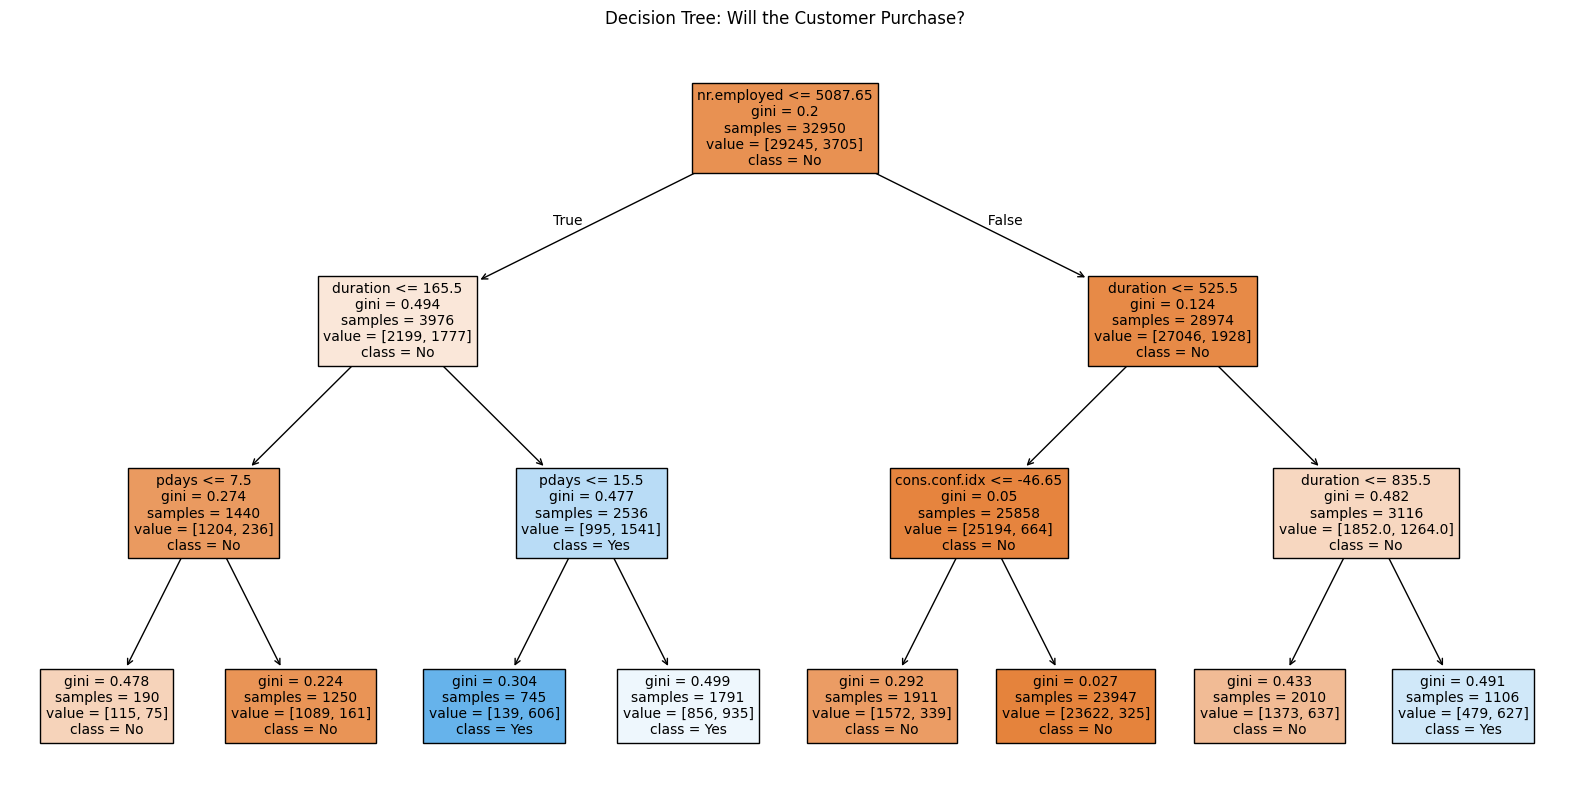

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import os

# --- STEP 1: AUTOMATIC FILE HUNTER ---
# This block searches every folder to find your file
target_files = ['bank-full.csv', 'bank-additional-full.csv', 'bank.csv']
file_path = None

print("🔍 Searching for dataset...")
for root, dirs, files in os.walk("."):
    for name in files:
        if name in target_files:
            file_path = os.path.join(root, name)
            print(f"✅ Found file at: {file_path}")
            break
    if file_path: break

if file_path is None:
    print("❌ ERROR: Could not find 'bank-full.csv' or 'bank-additional-full.csv'.")
    print("Please make sure you have unzipped the file if it's still a .zip archive.")
else:
    # --- STEP 2: LOAD DATA ---
    # The bank dataset uses semicolons ';' instead of commas
    df = pd.read_csv(file_path, sep=';')

    # Validation: If it didn't split correctly, try comma
    if df.shape[1] < 2:
        df = pd.read_csv(file_path, sep=',')

    print(f"📊 Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

    # --- STEP 3: PREPROCESS DATA ---
    # Convert text columns (like 'job', 'marital') to numbers
    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = le.fit_transform(df[col])

    # --- STEP 4: DEFINE X AND y ---
    # The target 'y' is usually the last column
    target_col = df.columns[-1]
    X = df.drop(target_col, axis=1)
    y = df[target_col]

    # --- STEP 5: TRAIN MODEL ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # We limit max_depth=3 so the tree is readable in the plot
    clf = DecisionTreeClassifier(max_depth=3, random_state=42)
    clf.fit(X_train, y_train)

    # --- STEP 6: EVALUATE ---
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n🎯 Model Accuracy: {accuracy*100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # --- STEP 7: VISUALIZE ---
    plt.figure(figsize=(20, 10))
    plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, fontsize=10)
    plt.title("Decision Tree: Will the Customer Purchase?")
    plt.show()